In [3]:
import pandas as pd
import os

#print(os.getcwd())
#df = pd.read_csv("cleaned_covid_10countries.csv")

df = pd.read_csv("../Data/cleaned_covid_10countries.csv")
print(df.head())
print(df.shape)
#print(df.dtypes)

# We have a problem as suspected before. Date is an "str". not the same time conversion we did on 01-cleaning.ipynb. We have to change it to 
# datetime 

df['date'] = pd.to_datetime(df['date'])
print(df.dtypes)

  iso_code     location        date  people_vaccinated_per_hundred  \
0      AFG  Afghanistan  2020-01-05                            NaN   
1      AFG  Afghanistan  2020-01-06                            NaN   
2      AFG  Afghanistan  2020-01-07                            NaN   
3      AFG  Afghanistan  2020-01-08                            NaN   
4      AFG  Afghanistan  2020-01-09                            NaN   

   new_deaths_smoothed_per_million  low/high  days_since_rollout  
0                              NaN         0              -414.0  
1                              NaN         0              -413.0  
2                              NaN         0              -412.0  
3                              NaN         0              -411.0  
4                              NaN         0              -410.0  
(16740, 7)
iso_code                                      str
location                                      str
date                               datetime64[us]
people_vaccinate

In [5]:
# Now, lets choose a country from our optons and attempt on making a days_since_rollout vs people_vaccinated_per_hundred:
# Low-income (5): Afghanistan, Ethiopia, Guinea, Malawi, Uganda
# High-income (5): Antigua and Barbuda, Belgium, Norway, Denmark, Seychelles

# Lets choose Belgium. High income country might have good data. Who knows

Belgium = df[df['location'] == 'Belgium']

#print(Belgium.head())
#print()

# Before that, I want to try something. I want to find the 5 number summary of the peak vaccinations_per_hundred for all countries.
# If you remember my first markdown from 01-cleaning.ipynb, I described "how fast" and "how far". Knowing this and seperaitng the countries
# by low-income and high-income can give us a distinguishing baseline to move along the research with. 

print(Belgium['people_vaccinated_per_hundred'].max()) # this gives one singular comparable value which is the max (or "how far")

# Using all numbers of 'people_vaccinated_per_hundred' is inefficient as those numbers are a time series going from 0 (when the epedemic begun)
# to, for example, for Belgium, 79.46 or "how far" Belgium got with its vaccination rates. A time series won't help us but it's peak 
# vaccination percentage can definately help us.

# the Logic is to essentially make a new list of all peak values for countries that are high/ low income seperately and use .describe 
# on both

HighIncome = df[df['low/high'] == 1]
ListForHigh = []

# Loop through the UNIQUE country names in the location 
for country in HighIncome['location'].unique():

    highData = HighIncome[HighIncome['location'] == country]
    max_value = highData['people_vaccinated_per_hundred'].max() 
    ListForHigh.append(max_value)

print(ListForHigh)
print()

LowIncome = df[df['low/high'] == 0]
listForLow = []

for country in LowIncome['location'].unique():

    lowData = LowIncome[LowIncome['location'] == country]
    max_value = lowData['people_vaccinated_per_hundred'].max()
    listForLow.append(max_value)

print(listForLow)

# To use .describe, I would have to convert this into a series or df. Ill do series

listForHigh = pd.Series(ListForHigh)
listForLow = pd.Series(listForLow)

print()
print(listForHigh.describe())
print()
print(listForLow.describe())


79.46
[np.float64(68.56), np.float64(79.46), np.float64(80.69), np.float64(79.99), np.float64(82.62)]

[np.float64(46.56), np.float64(42.54), np.float64(62.89), np.float64(26.63), np.float64(42.4)]

count     5.000000
mean     78.264000
std       5.555117
min      68.560000
25%      79.460000
50%      79.990000
75%      80.690000
max      82.620000
dtype: float64

count     5.000000
mean     44.204000
std      12.938181
min      26.630000
25%      42.400000
50%      42.540000
75%      46.560000
max      62.890000
dtype: float64


## Descriptive Statistical Observations

[Note: The first set of numbers represent High-income countries and the second set of numbers represent Low-income countries]

The high Income countries have a peak vaccination percentage mean of 78.26 compared to 44.204 of the low income countries. This tells me that higher income countries, on average, had higher vaccination reaches than lower income countries. This confirms a hypothesis I had originally about high income vs low income as Lower-income countries struggle with funds for healthcare, not having the ability to buy from major phramacutical companies and major geographic/cultural barriers. We should expect to see data where high-income countries have higher vaccination rates than lower-income countries. When looking at standard deviations, I see that high-income countries have an STD of 5.55.. while low income countries have 12.938.. . This also follows up with my hypothesis as higher-income countries would often succeed in providing vaccinations as governments are more capable of protecting their population when looking at it through a financial or structural basis than lower-income countries. This doesn't mean lower income countries aren't capable, this means that not all lower-income countries are as capable explaining why there is high variability among them. 

One thing to consider is that both are very very small samples of 5 countries (total of 10 out of ~237) which means high variablity in either, high income or low income, is to be expected.


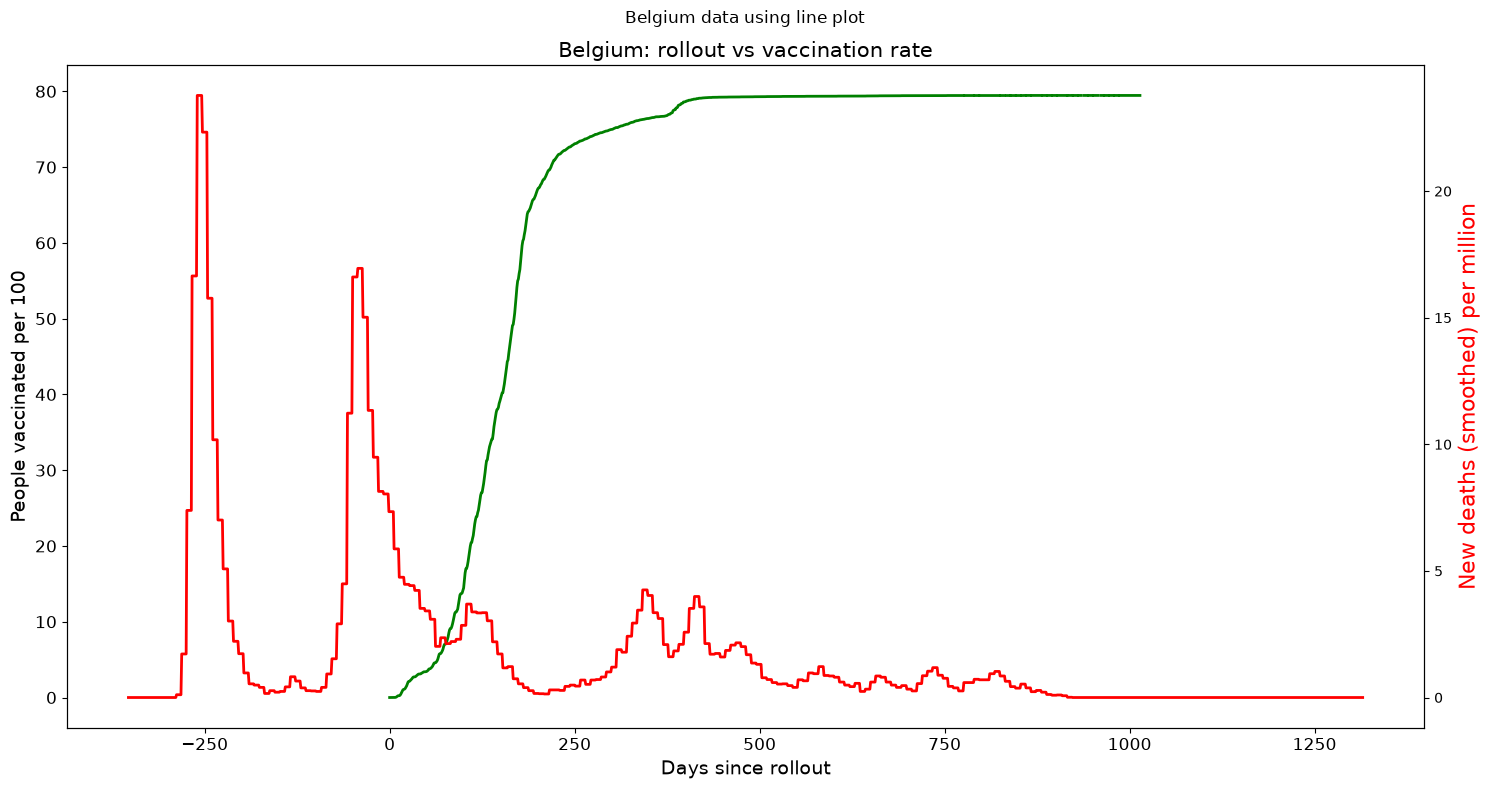

In [6]:
# Now, lets try to make a plot. For now, one country to see how it looks
# x axis: days_since_rollout 
# y axis: people_vaccinated_per_hundred

import matplotlib.pyplot as plt 

fig, axes = plt.subplots(1,1, figsize = (15,8))
axes.set_title('Belgium: rollout vs vaccination rate', fontsize=15)
axes.set_xlabel('Days since rollout', fontsize = 14)
axes.set_ylabel('People vaccinated per 100', fontsize = 14)

# A line plot is the best kind of plot that we can use to make as it shows change over time that directly relates to the question

x_data = Belgium['days_since_rollout']
y_data = Belgium['people_vaccinated_per_hundred']

axes.plot(x_data, y_data, color = 'green', linewidth = 2)
axes.tick_params(axis='both', labelsize = 12)

# This plot shows an interesting but predictable diagram. this shows "how far" by the highest y value and "how quick" using slopes. 
# The fact that the slope plateau's or flattens eventually gives us the exact idea that no country could ever heal 100% of their 
# population, same applies for Belgium. 

# But now, we only added one of the needed variables, we also have to add 'new_deaths_people_smoothed_per_million'  
# Lets make a 2nd y axis on the same plot to ensure we can compare the data on the same plot 

ax2 = axes.twinx() # Second y axis
death_data = Belgium['new_deaths_smoothed_per_million'] 
ax2.plot(x_data, death_data, color='red', linewidth=2, label='Deaths per million')
ax2.set_ylabel('New deaths (smoothed) per million', color='red', fontsize = 16)
 
plt.suptitle('Belgium data using line plot')
plt.tight_layout()
plt.show()

# We see a predictable pattern

## Observations

I see a predictable pattern here. As vaccination rates increase, the number of deaths smoothed per million decreases which is quite ideal for any country but its not a smooth decline. We see multiple bumps that occur after day 0. Day 0 is the first day of rollout for the given country.

I like to believe that all bumps after day 0 are caused due to this: resistance/scared of vaccination due to previous failures, people not following orders of government on curfews or what not to do during covid (basically lethargy towards following policies). The first bump can specifically be addressed by the AstraZeneca Shortfalls which were shortages in vaccinations around 2021. Google also says that sudden rises might be caused due to waning vaccine affects, weaker inmmuities, lifting up of governemental restrictions. 

While these are plausible reasons, I would like to say that none of these are established facts. These are mostly hypotheseses.

NOTE: 
Green line: people vaccinated per 100, Red Line: new deaths smoothed per million

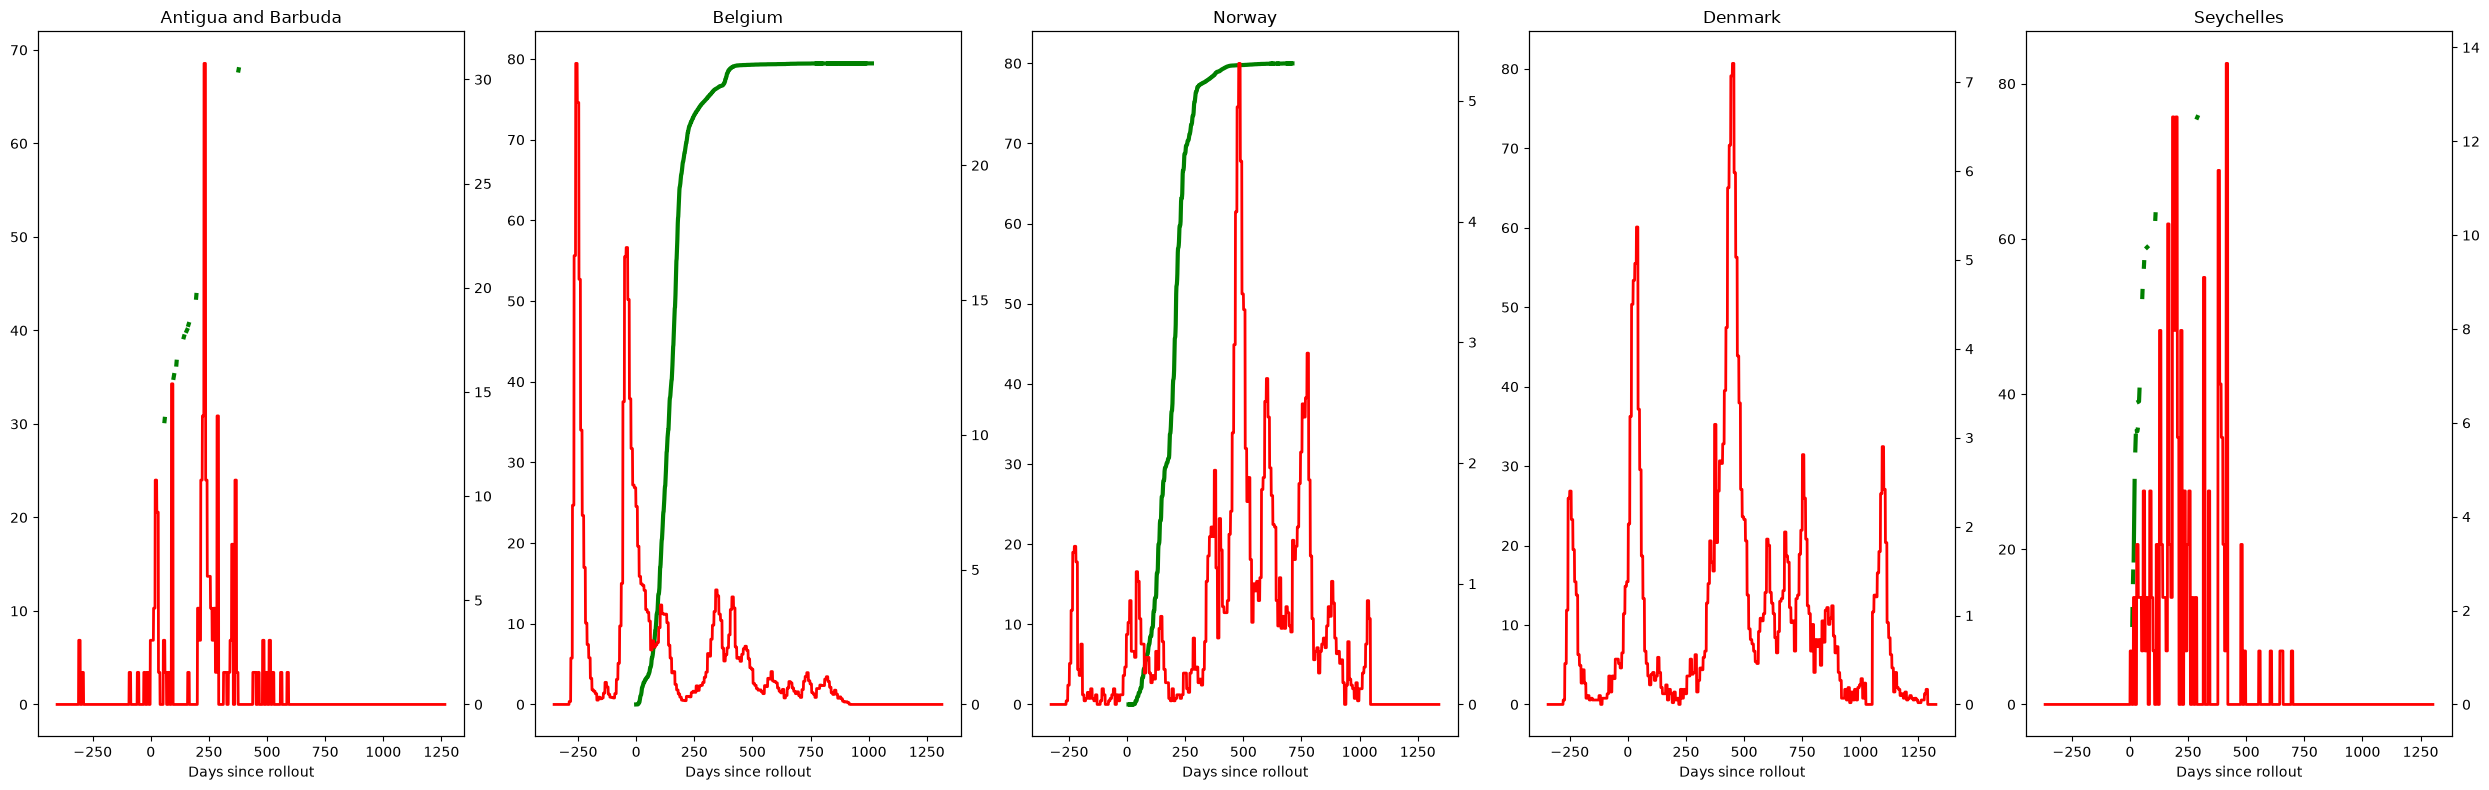

In [ ]:
# Now, lets make a loop for all high income countries. We will make a similar graph for all these countries to look at it side by side

high_income_countries = ["Antigua and Barbuda", "Belgium", "Norway", "Denmark", "Seychelles"]

fig, axes = plt.subplots(1, 5, figsize=(25, 8))

for i, country in enumerate(high_income_countries):
    countryData = df[df['location'] == country]
    x = countryData['days_since_rollout']
    y_vax = countryData['people_vaccinated_per_hundred']
    y_death = countryData['new_deaths_smoothed_per_million']

    ax1 = axes[i]
    ax1.plot(x, y_vax, color='green', linewidth=3)
    ax1.set_title(country)
    ax1.set_xlabel('Days since rollout')

    ax2 = ax1.twinx()
    ax2.plot(x, y_death, color='red', linewidth=2)

plt.tight_layout()
plt.show()

## Observations

We see that all countries had their own trends and that Norway and Belgium are the only two countries to give us clear data. Clear means where you can see a trend on both variables: Green line: people vaccinated per 100 and Red Line: new deaths smoothed per million. Antigua and Barbuda, Denmark and Seychelles all have missing 'people vaccinated per 100'. This is because, when we randomly picked these 5 countries in 01-cleaning.ipynb, they did pass the 88% cutoff of percentage loss but their percentage losses were still high. The numbers went like this:

     country  loss of data due to null (%)  
   Antigua and Barbuda:      83.737024  
              Belgium:                                                                                      2.857143 
               Norway:                                                                                       1.966292  
              Denmark:                                                                                    85.629921  
         Seychelles:                                                                                   87.332521  

Now, as we see, Norway and Belgium have lesser than 5% loss of data making their lines crystal clear while the rest had over 50% of their data missing making complete sense for their green line to be in scattered lines or completely nonexsistant. 

When we look at the people smoothed per million, we see that the ideal pattern we saw in belgium doesn't follow up everywhere. By the scattered points we have, we can see that vaccinated people per 100 did, in fact increase in all countries, but this did not mean new deaths reduced as we see so many peaks even after day 0. These peaks are much much lower than Belgium's as we see Belgium has a y axis up to 25-30 while other countries (except Antigua and Barbuda) have their deaths per million below 15. This shows that Belgium might have had a steadier (compared to the rest) decline from a really high (comparative to the rest of countries here) death rate while others had lower but inconsistent declines in death rate.

I must acknowledge on one claim I made here, the idea that most countries did have an increase in vaccination comes from a scattered non-continous dataset which is not ideal. I came to that conclusion by seeing that the green dots were increasing. Its not a defined fact but its an observation. This doesn't apply to Denmark as no Green points are visible.

One more thing, visually, only Belgium and Norway show a clear enough pattern to informally suggest a possible link between rising vaccination and falling deaths; the other three high-income countries are too data-sparse to draw even an informal visual conclusion, which itself is a limitation of this dataset rather than evidence against the hypothesis.

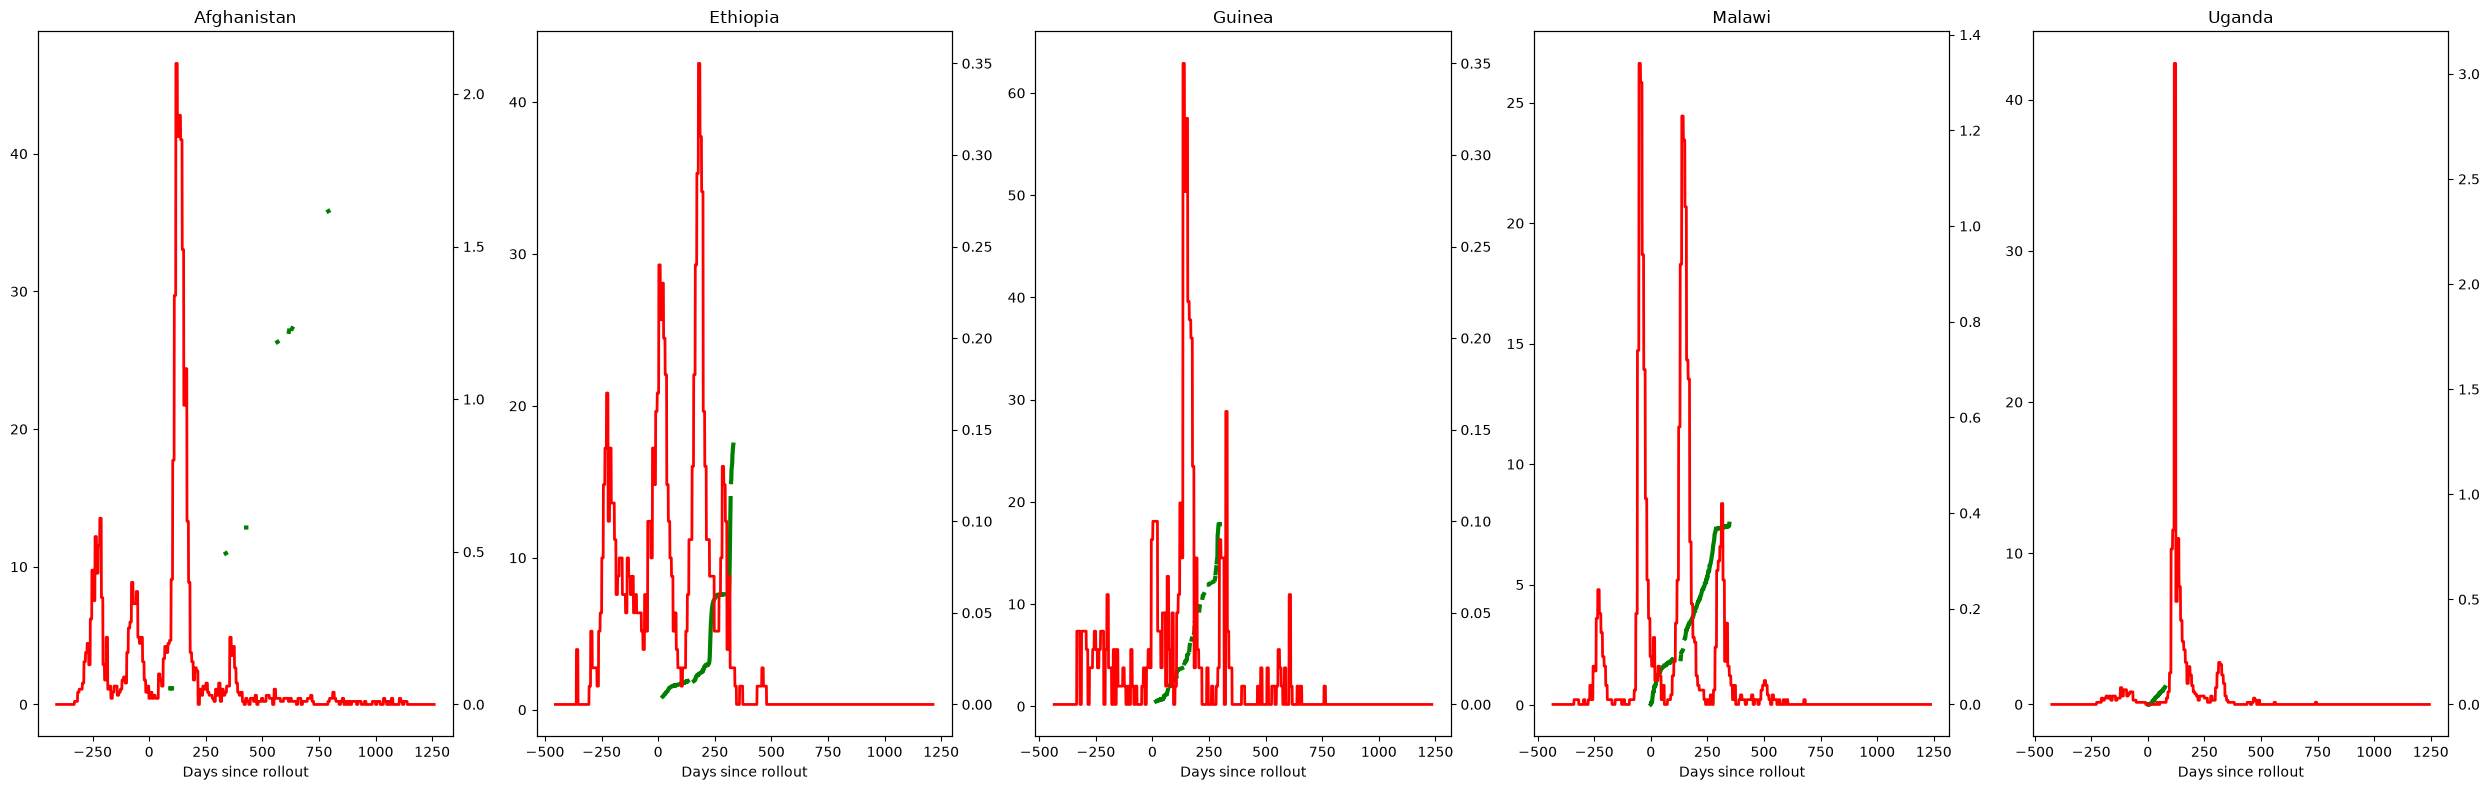

In [12]:
low_income_countries = ['Afghanistan', 'Ethiopia', 'Guinea', 'Malawi', 'Uganda']

fig, axes = plt.subplots(1, 5, figsize=(25, 8))

for i, country in enumerate(low_income_countries):
    countryData = df[df['location'] == country]
    x = countryData['days_since_rollout']
    y_vax = countryData['people_vaccinated_per_hundred']
    y_death = countryData['new_deaths_smoothed_per_million']

    ax1 = axes[i]
    ax1.plot(x, y_vax, color='green', linewidth=3)
    ax1.set_title(country)
    ax1.set_xlabel('Days since rollout')

    ax2 = ax1.twinx()
    ax2.plot(x, y_death, color='red', linewidth=2)

plt.tight_layout()
plt.show()

## Observations

Similar to the high-income group, low-income countries showed a wide range of data quality. All 5 low-income countries (Afghanistan, Ethiopia, Guinea, Malawi, Uganda) had percentage losses between 80-87%, meaning this entire group was consistently close to the 88% cutoff — unlike the high-income group, where at least two countries (Belgium, Norway) had very clean data. This means the green line (people vaccinated per 100) appears scattered or nearly invisible across all five low-income countries, not just some of them.

Because of this, I cannot confidently claim that vaccination rates were "lower" in these countries based on the visible green points alone — the sparsity itself makes any trend hard to confirm, the same issue identified with Antigua and Barbuda, Denmark, and Seychelles.

What I can confidently observe is the death rate (red line) scale: all five low-income countries show right-axis values far smaller than Belgium's (mostly under 3, several under 0.5), compared to Belgium's 25-30. This is a real, visible difference, not an artifact of missing data. Possible explanations include a younger population age structure and lower rates of comorbidities like diabetes, both of which reduce COVID mortality risk independent of vaccination — this is a hypothesis based on general epidemiological knowledge, not something directly tested by this dataset.

I also notice multiple death peaks across all five countries, consistent with distinct COVID waves (e.g., Delta, Omicron) rather than one clean outbreak-then-recovery pattern, similar to what was seen in the high-income group.

Given the severity of missing vaccination data across this entire group, I expect the low-income Mann-Kendall results to carry more uncertainty than the high-income results — any weak or non-significant trend found here may reflect data sparsity as much as (or more than) the true underlying relationship. This is a limitation I will carry forward into the analysis and discussion sections. 

## Purpose of 02-eda.ipynb

This exploration stress tests the idea that I could use Mann Kendall's test (a test I will use in the next file). While I saw a lot of variance in Countries like most low income countries and countries like Denmark, I can still get pretty useful and siginficant values from Countries like Norway and Belgium that can be used to answer our question.

I place this explaination here because the test I will use in 03-analysis.ipynb has data that was last changed in 01-cleaning.ipynb, meaning this file didn't change anything. This file, at first, might not seem very important as I make observations but don't use them in 03-analysis.ipynb, but it actually serves an important purpose. By this file, I am now aware on which countries data can be trusted and which countries to be careful with. Some countries have a lot of scattered points while others have a perfect graph. Scattered points cannot be interpretted properly as values are missing and so I have to be careful with them. 